<a href="https://colab.research.google.com/github/AJPardhiv/ML-Lab/blob/main/Week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Original Data Shape: (150, 4)

Explained Variance Ratio:
Principal Component 1: 0.7296
Principal Component 2: 0.2285

Cumulative Explained Variance: [0.72962445 0.95813207]


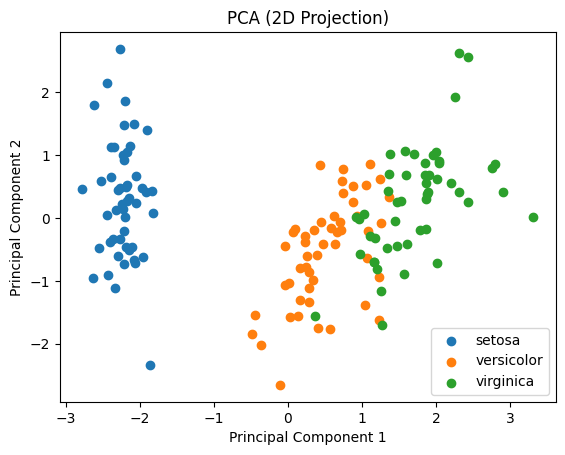

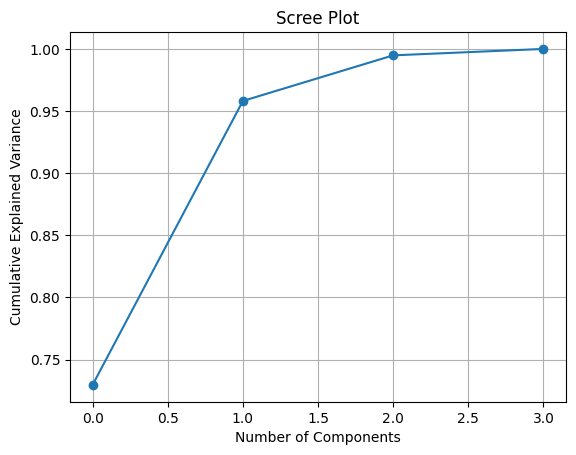

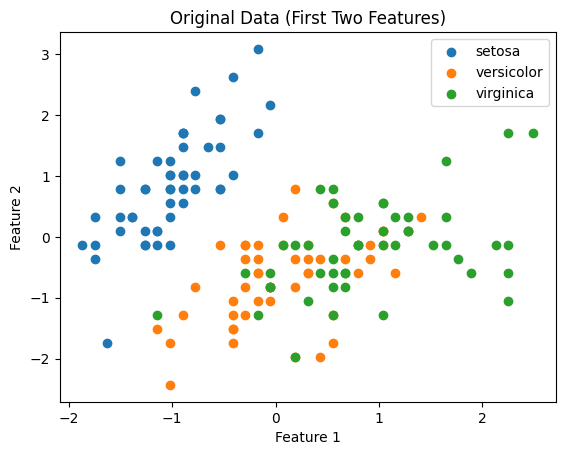

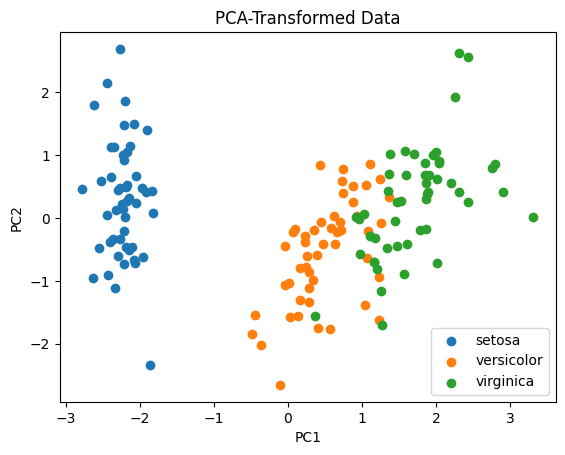

In [1]:
# Experiment-3: Standardization, Normalization, PCA (2 Components), Explained Variance, 2D Visualization, Scree Plot,
#              and Original vs PCA-Transformed Visualization (Iris Dataset)

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# -------------------------------
# 1) Load Iris Dataset
# -------------------------------
# Title: Load Iris Dataset
data = load_iris()
X = data.data
y = data.target
target_names = data.target_names

print("Original Data Shape:", X.shape)

# -------------------------------
# 2) Apply Standardization
# -------------------------------
# Title: Apply StandardScaler (Standardization)
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

# -------------------------------
# 3) Apply Normalization
# -------------------------------
# Title: Apply MinMaxScaler (Normalization)
minmax = MinMaxScaler()
X_normalized = minmax.fit_transform(X)

# -------------------------------
# 4) Apply PCA (2 Components)
# -------------------------------
# Title: PCA Dimensionality Reduction to 2 Components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_standardized)

# -------------------------------
# 5) Explained Variance Ratio
# -------------------------------
# Title: Explained Variance Ratio and Cumulative Explained Variance
print("\nExplained Variance Ratio:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Principal Component {i+1}: {var:.4f}")

print("\nCumulative Explained Variance:", np.cumsum(pca.explained_variance_ratio_))

# -------------------------------
# 6) Visualize Data in 2D (PCA)
# -------------------------------
# Title: 2D Visualization using First Two Principal Components
plt.figure()
for i, target in enumerate(target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=target)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA (2D Projection)")
plt.legend()
plt.show()

# -------------------------------
# 7) Scree Plot (Cumulative Explained Variance)
# -------------------------------
# Title: Scree Plot (Cumulative Explained Variance)
pca_full = PCA()
pca_full.fit(X_standardized)

plt.figure()
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.grid()
plt.show()

# -------------------------------
# 8) Compare Original vs PCA-Transformed Visualization
# -------------------------------
# Title: Original vs PCA-Transformed Data Visualization

# Original data (first two standardized features)
plt.figure()
for i, target in enumerate(target_names):
    plt.scatter(X_standardized[y == i, 0], X_standardized[y == i, 1], label=target)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Original Data (First Two Features)")
plt.legend()
plt.show()

# PCA-transformed data
plt.figure()
for i, target in enumerate(target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=target)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA-Transformed Data")
plt.legend()
plt.show()

**POST LAB**

Original Data Shape: (150, 4)

Explained Variance Ratio (PCA 2 components):
PC1: 0.7296
PC2: 0.2285
Cumulative Explained Variance: [0.72962445 0.95813207]


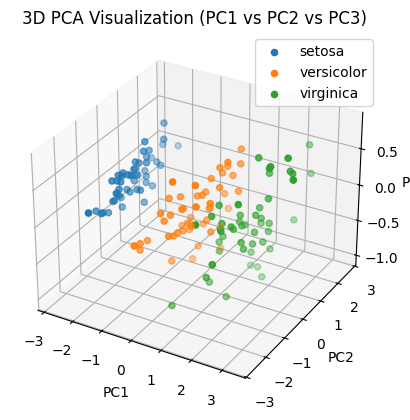


Cumulative Explained Variance by #Components:
1 component(s): 0.7296
2 component(s): 0.9581
3 component(s): 0.9948
4 component(s): 1.0000


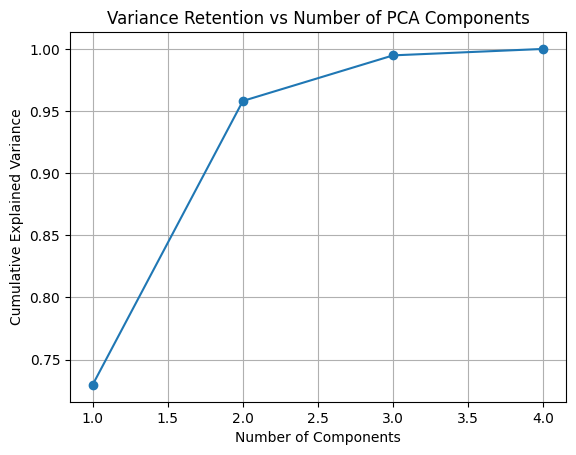

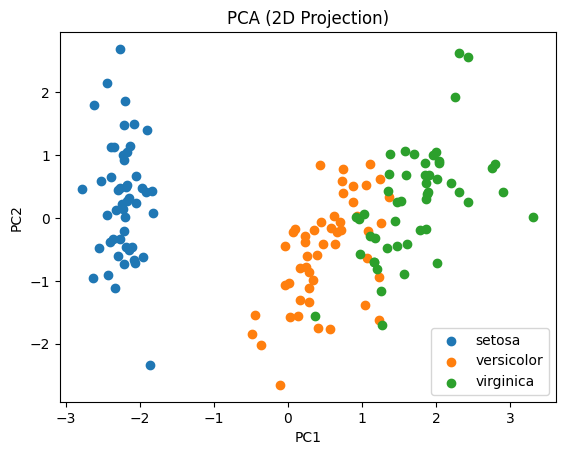

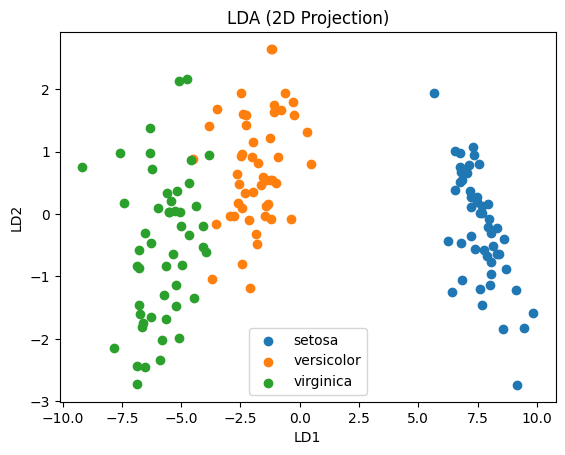

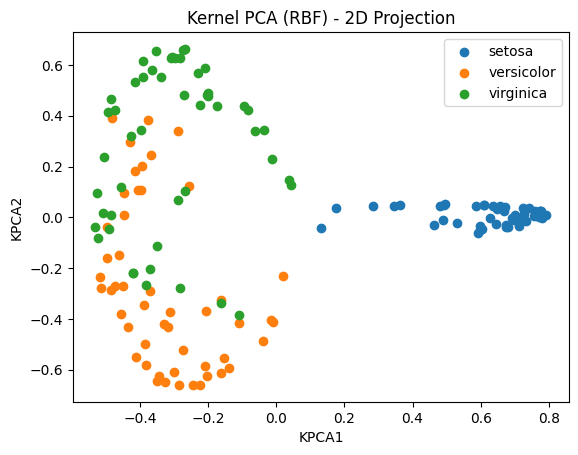


Reconstruction Error (MSE) for Different PCA Dimensions:
PCA with 1 component(s): MSE = 0.270376
PCA with 2 component(s): MSE = 0.041868
PCA with 3 component(s): MSE = 0.005179
PCA with 4 component(s): MSE = 0.000000


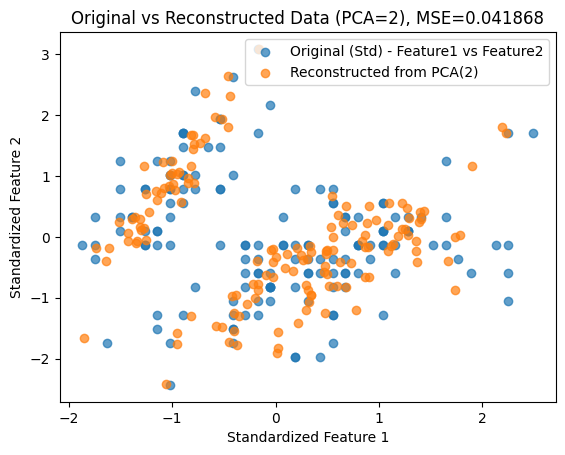

In [3]:
# Post-Lab Extension: 3D PCA Visualization, Variance Retention vs #Components, PCA vs LDA, Kernel PCA,
#                    and Reconstruction Error (Iris Dataset)

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# -----------------------------------
# 1) Load Iris Dataset
# -----------------------------------
# Title: Load Iris Dataset
data = load_iris()
X = data.data
y = data.target
target_names = data.target_names

print("Original Data Shape:", X.shape)  # (150, 4)

# -----------------------------------
# 2) Standardization + Normalization
# -----------------------------------
# Title: Standardization (StandardScaler) and Normalization (MinMaxScaler)
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

minmax = MinMaxScaler()
X_norm = minmax.fit_transform(X)

# -----------------------------------
# 3) PCA (2 Components) + Explained Variance
# -----------------------------------
# Title: PCA (2 Components) + Explained Variance
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_std)

print("\nExplained Variance Ratio (PCA 2 components):")
for i, var in enumerate(pca2.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.4f}")
print("Cumulative Explained Variance:", np.cumsum(pca2.explained_variance_ratio_))

# -----------------------------------
# 4) 3D Visualization using First Three Principal Components
# -----------------------------------
# Title: 3D PCA Visualization (First 3 PCs)
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_std)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for i, name in enumerate(target_names):
    ax.scatter(
        X_pca3[y == i, 0],
        X_pca3[y == i, 1],
        X_pca3[y == i, 2],
        label=name
    )

ax.set_title("3D PCA Visualization (PC1 vs PC2 vs PC3)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()
plt.show()

# -----------------------------------
# 5) PCA with Different Numbers of Components (Variance Retention)
# -----------------------------------
# Title: Variance Retention for Different PCA Component Counts
pca_full = PCA()
pca_full.fit(X_std)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

print("\nCumulative Explained Variance by #Components:")
for k in range(1, X.shape[1] + 1):
    print(f"{k} component(s): {cum_var[k-1]:.4f}")

plt.figure()
plt.plot(range(1, X.shape[1] + 1), cum_var, marker='o')
plt.title("Variance Retention vs Number of PCA Components")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

# -----------------------------------
# 6) Compare PCA with LDA (Linear Discriminant Analysis)
# -----------------------------------
# Title: PCA vs LDA Comparison (2D Projection)
# PCA (2D) already computed as X_pca2

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda2 = lda.fit_transform(X_std, y)

# PCA 2D plot
plt.figure()
for i, name in enumerate(target_names):
    plt.scatter(X_pca2[y == i, 0], X_pca2[y == i, 1], label=name)
plt.title("PCA (2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

# LDA 2D plot
plt.figure()
for i, name in enumerate(target_names):
    plt.scatter(X_lda2[y == i, 0], X_lda2[y == i, 1], label=name)
plt.title("LDA (2D Projection)")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()
plt.show()

# -----------------------------------
# 7) Kernel PCA for Non-Linear Dimensionality Reduction
# -----------------------------------
# Title: Kernel PCA (RBF Kernel) - 2D Projection
kpca = KernelPCA(n_components=2, kernel="rbf", gamma=0.5)
X_kpca2 = kpca.fit_transform(X_std)

plt.figure()
for i, name in enumerate(target_names):
    plt.scatter(X_kpca2[y == i, 0], X_kpca2[y == i, 1], label=name)
plt.title("Kernel PCA (RBF) - 2D Projection")
plt.xlabel("KPCA1")
plt.ylabel("KPCA2")
plt.legend()
plt.show()

# -----------------------------------
# 8) Reconstruct Data from Reduced Dimensions + Reconstruction Error
# -----------------------------------
# Title: Reconstruction from PCA + Reconstruction Error (MSE)

def reconstruction_error(pca_model, X_scaled):
    X_reduced = pca_model.transform(X_scaled)
    X_reconstructed = pca_model.inverse_transform(X_reduced)
    mse = np.mean((X_scaled - X_reconstructed) ** 2)
    return mse, X_reconstructed

print("\nReconstruction Error (MSE) for Different PCA Dimensions:")
for n in range(1, X.shape[1] + 1):
    pca_n = PCA(n_components=n)
    pca_n.fit(X_std)
    mse, _ = reconstruction_error(pca_n, X_std)
    print(f"PCA with {n} component(s): MSE = {mse:.6f}")

# Visualize Original vs Reconstructed (example: n_components=2)
pca_recon2 = PCA(n_components=2)
pca_recon2.fit(X_std)
mse2, X_recon2 = reconstruction_error(pca_recon2, X_std)

plt.figure()
plt.scatter(X_std[:, 0], X_std[:, 1], label="Original (Std) - Feature1 vs Feature2", alpha=0.7)
plt.scatter(X_recon2[:, 0], X_recon2[:, 1], label="Reconstructed from PCA(2)", alpha=0.7)
plt.title(f"Original vs Reconstructed Data (PCA=2), MSE={mse2:.6f}")
plt.xlabel("Standardized Feature 1")
plt.ylabel("Standardized Feature 2")
plt.legend()
plt.show()